# Question 9

## Loading Data

In [15]:
import cv2
import numpy as np
import glob
import os


def load_data(folder_path):
    file_pattern = os.path.join(folder_path, '*.jpg')
    image_files = glob.glob(file_pattern)

    dataset = []

    for file_path in image_files:
        filename = os.path.basename(file_path)
        true_label = None
        if filename.startswith('c'):
            true_label = 'c'
        elif filename.startswith('s'):
            true_label = 's'
        img = cv2.imread(file_path)
        if img is None:
            print(f"Failed to load {filename}")
            continue

        dataset.append((img, true_label, filename))

    print(f"Successfully loaded {len(dataset)} images.\n")
    return dataset


FOLDER_PATH = 'Images'
loaded_dataset = load_data(FOLDER_PATH)

Successfully loaded 80 images.



## Part 2: Defining Classifiers:
Here we defined 2 classifiers, one of them classify images based on average blueness of the picture, the other classify them based on the saturation of the images.

In [16]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix


def classify_images_saturation(dataset, threshold):
    y_true = []
    y_pred = []

    for (img, true_label, filename) in dataset:
        hsv_image = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        avg_saturation = np.mean(hsv_image[:, :, 1])
        predicted_label = 'c' if avg_saturation < threshold else 's'
        y_true.append(true_label)
        y_pred.append(predicted_label)

    return y_true, y_pred


def classify_images_blueness(dataset, threshold):
    y_true = []
    y_pred = []

    for (img, true_label, filename) in dataset:
        avg_B = np.mean(img[:, :, 0])
        avg_G = np.mean(img[:, :, 1])
        avg_R = np.mean(img[:, :, 2])
        if (avg_B > avg_R + threshold) and (avg_B > avg_G + threshold):
            predicted_label = 's'
        else:
            predicted_label = 'c'

        y_true.append(true_label)
        y_pred.append(predicted_label)

    return y_true, y_pred


def evaluate_classification(y_true, y_pred, threshold):
    print("\n--- Classification Report ---")
    labels_order = ['s', 'c']

    print("## Confusion Matrix")
    cm = confusion_matrix(y_true, y_pred, labels=labels_order)

    print(f"Labels: {labels_order}")
    print(cm)

    print("\n## Classification Report")

    target_names = ['clear sky (s)', 'cloudy (c)']
    report = classification_report(
        y_true, y_pred, labels=labels_order, target_names=target_names)

    print(report)

### Seperating Data to train and test:

In [17]:
from sklearn.model_selection import train_test_split

images = [item[0] for item in loaded_dataset]
labels = [item[1] for item in loaded_dataset]

X_train, X_test, y_train, y_test = train_test_split(
    images, labels, test_size=0.3, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 56
Testing set size: 24


### Finding best threshold for each classifier using grid search

In [18]:
from sklearn.metrics import accuracy_score


def find_best_threshold_blueness(dataset, thresholds):
    best_threshold = None
    best_accuracy = 0

    for threshold in thresholds:
        y_true, y_pred = classify_images_blueness(
            dataset, threshold)
        accuracy = accuracy_score(y_true, y_pred)

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_threshold = threshold

    print(
        f"Best blueness threshold: {best_threshold} with accuracy: {best_accuracy}")
    return best_threshold


def find_best_threshold_saturation(dataset, thresholds):
    best_threshold = None
    best_accuracy = 0

    for threshold in (thresholds):
        y_true, y_pred = classify_images_saturation(dataset, threshold)
        accuracy = accuracy_score(y_true, y_pred)

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_threshold = threshold

    print(
        f"Best saturation threshold: {best_threshold} with accuracy: {best_accuracy}")
    return best_threshold


thresholds = range(10, 300, 5)

best_blueness_threshold = find_best_threshold_blueness(
    loaded_dataset, thresholds)
best_saturation_threshold = find_best_threshold_saturation(
    loaded_dataset, thresholds)

Best blueness threshold: 25 with accuracy: 0.5125
Best saturation threshold: 85 with accuracy: 0.8375


### Model evaluation:

In [19]:
print("\nEvaluation using best blueness threshold:")
y_true_blueness, y_pred_blueness = classify_images_blueness(
    zip(X_test, y_test, [None]*len(X_test)), best_blueness_threshold)
evaluate_classification(y_true_blueness, y_pred_blueness,
                        best_blueness_threshold)

print("\nEvaluation using best saturation threshold:")
y_true_saturation, y_pred_saturation = classify_images_saturation(
    zip(X_test, y_test, [None]*len(X_test)), best_saturation_threshold)
evaluate_classification(
    y_true_saturation, y_pred_saturation, best_saturation_threshold)


Evaluation using best blueness threshold:

--- Classification Report ---
## Confusion Matrix
Labels: ['s', 'c']
[[ 0 14]
 [ 0 10]]

## Classification Report
               precision    recall  f1-score   support

clear sky (s)       0.00      0.00      0.00        14
   cloudy (c)       0.42      1.00      0.59        10

     accuracy                           0.42        24
    macro avg       0.21      0.50      0.29        24
 weighted avg       0.17      0.42      0.25        24


Evaluation using best saturation threshold:

--- Classification Report ---
## Confusion Matrix
Labels: ['s', 'c']
[[13  1]
 [ 4  6]]

## Classification Report
               precision    recall  f1-score   support

clear sky (s)       0.76      0.93      0.84        14
   cloudy (c)       0.86      0.60      0.71        10

     accuracy                           0.79        24
    macro avg       0.81      0.76      0.77        24
 weighted avg       0.80      0.79      0.78        24



/home/wren/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/wren/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/wren/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


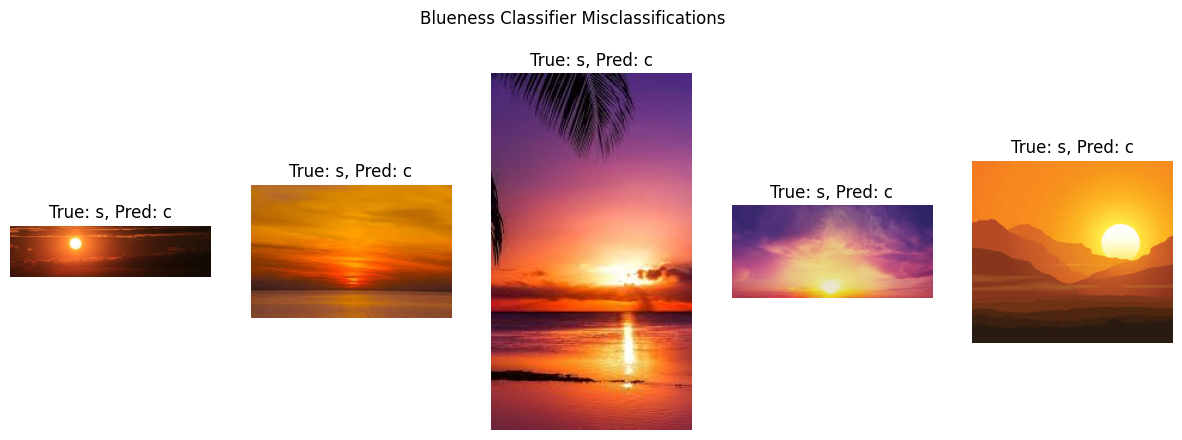

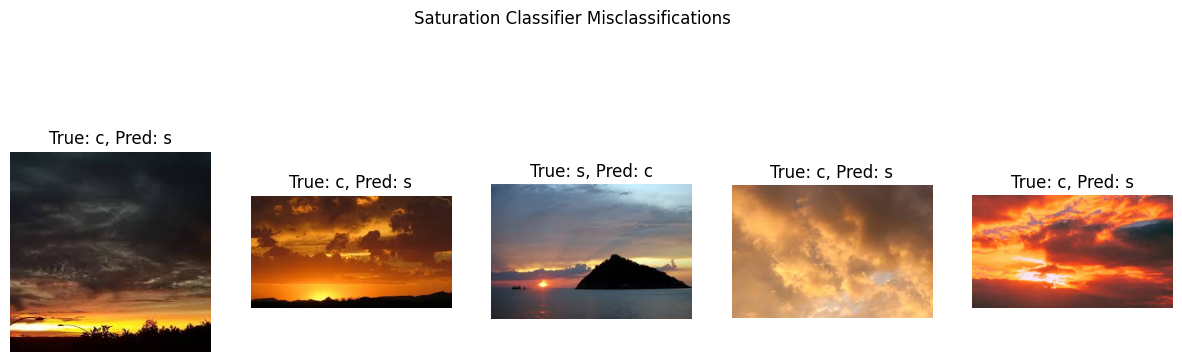

In [20]:
import matplotlib.pyplot as plt


def show_misclassified_images(images, y_true, y_pred, title, num_images=5):
    misclassified_indices = [i for i, (true, pred) in enumerate(
        zip(y_true, y_pred)) if true != pred]
    num_to_show = min(len(misclassified_indices), num_images)

    if num_to_show == 0:
        print(f"No misclassified images found for {title}.")
        return

    plt.figure(figsize=(15, 5))
    for i in range(num_to_show):
        idx = misclassified_indices[i]
        plt.subplot(1, num_to_show, i + 1)
        plt.imshow(cv2.cvtColor(images[idx], cv2.COLOR_BGR2RGB))
        plt.title(f"True: {y_true[idx]}, Pred: {y_pred[idx]}")
        plt.axis('off')
    plt.suptitle(title)
    plt.show()


show_misclassified_images(X_test, y_true_blueness,
                          y_pred_blueness, "Blueness Classifier Misclassifications")

show_misclassified_images(X_test, y_true_saturation,
                          y_pred_saturation, "Saturation Classifier Misclassifications")

### Explanation of results:
We used two criterions, One decided based on the blueness of the image and the other decided based on the saturation of the images.

The first classifier(Blueless) performed poorly(almost random) since even sunny pictures had a blue sky in them and the criterion couldn't distinguish them.
We can see this in the pictures of misclassification of blueness, in the third and fourth misclassified pictures.

The saturation criterion worked better and reached a test accuracy of 0.79 percent. This classifier tries to classify images with more vivid colors as sunny and others as cloudy.

As we can see in the misclassified images, most of this criterions wrong decisions comes from existance of a sum behind the clouds that would make the picture more vivid and make the model believe that it is sunny while the sun is behind the coulds.